In [11]:
import warnings
import logging

# Desactivar warnings y reducir el logging en este notebook

# Ignorar warnings generales y categorías comunes
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Ajustar nivel de logging global y para librerías ruidosas
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)
logging.getLogger("sklearn").setLevel(logging.ERROR)
logging.getLogger("numba").setLevel(logging.ERROR)
logging.getLogger("urllib3").setLevel(logging.ERROR)

# Ignorar warnings numéricos de numpy (si aplica)
# np ya está importado en el notebook; no volver a importarlo para no sobrescribir
try:
    np.seterr(all="ignore")
except NameError:
    # Si np no está definido en este entorno, se ignora este paso
    pass

#print("Warnings desactivados y logging limitado a ERROR para este notebook.")

# Optimización Avanzada de Modelos en Ciencia de Datos

## Fundamentos de la Calidad y Cantidad de Datos

La optimización de un modelo de aprendizaje automático trasciende la simple selección de un algoritmo o la sintonización de sus parámetros; constituye un proceso holístico que comienza mucho antes de iniciar el entrenamiento y se fundamenta en dos pilares ineludibles: la calidad intrínseca de los datos y una comprensión matizada de su volumen. Ignorar estos aspectos no solo limita el potencial del modelo, sino que introduce sesgos sistémicos que pueden invalidar cualquier esfuerzo posterior de optimización. La calidad de los datos define la capacidad de un conjunto para cumplir su propósito final, que en este caso es alimentar un modelo predictivo. Esta noción multidimensional va más allá de la simple ausencia de errores y abarca seis dimensiones clave: precisión (conformidad con la realidad), completitud (captura exhaustiva de todos los atributos relevantes), puntualidad (actualidad de la información), consistencia (sincronización entre diferentes fuentes de datos), validez (adherencia a formatos y reglas predefinidas) e integridad (capacidad de fusionar conjuntos de datos manteniendo relaciones lógicas correctas). Un marco especializado como METRIC-framework amplía esta perspectiva al incluir la representatividad del conjunto de datos (variedad en demografía y fuentes) y la conciencia informacional (redundancia, unicidad, importancia de las características). El impacto económico de la mala calidad es tangible y masivo; se estima que el 80% de las empresas sufren pérdidas anuales de entre 10 y 14 millones de dólares debido a datos deficientes, y un estudio reveló que el 70% de los ejecutivos admiten recopilar datos a un ritmo superior al que pueden ser procesados y utilizados eficazmente. Estos problemas se manifiestan en fallos de cascada dentro de los pipelines de ML, desde la superestimación del poder predictivo en datasets pequeños hasta la incapacidad para diagnosticar correctamente el origen del fracaso, confundiéndolo a menudo con un problema de modelado cuando en realidad reside en la infraestructura de datos.

El principio de "basura entra, basura sale" (garbage in, garbage out) adquiere una dimensión empírica precisa en este dominio. Investigaciones han demostrado que los conjuntos de datos pequeños, típicamente con menos de 300 muestras (N ≤ 300), sistematicamente sobreestiman el poder predictivo de los modelos debido a un sobreajuste severo, lo que resulta en una brecha significativa entre el rendimiento en validación cruzada y el test (CV-test AUC gap de hasta 0.12). Este hallazgo subraya que la falta de datos de alta calidad, en este caso suficiente volumen, invalida fundamentalmente el proceso de optimización. Más allá del volumen, la relevancia de las características, medida por su importancia predictiva, ha demostrado ser tan crucial como el tamaño del propio dataset en muchas tareas de IA centrada en los datos. Por lo tanto, la gestión de la calidad de los datos debe concebirse como un proceso continuo y automatizado, integrado en cada etapa del ciclo de vida del dato: ingestión, transformación, revisión de código (pull requests) y producción. Herramientas como DeeQu de Amazon, un framework basado en Spark, permiten la validación escalable mediante el cálculo de métricas y la verificación de restricciones definidas por el usuario, pudiendo incluso sugerir automáticamente reglas de validación a partir del perfilado de datos. Para el científico de datos moderno, dominar estas prácticas de observabilidad de datos no es una opción, sino una competencia fundamental para garantizar la viabilidad y fiabilidad de los proyectos de ML.

Paralelamente a la calidad, la cantidad de muestras es un factor crítico y no lineal en la optimización. La creencia popular de que "más datos siempre es mejor" es un simplismo que ignora la dinámica del rendimiento decreciente. Los estudios empíricos muestran que existe un punto de saturación donde la mejora en el rendimiento se desacelera drásticamente. Una investigación sobre el aprendizaje profundo encontró que la reducción del error sigue una ley de escalamiento de potencia con respecto al número de instancias de entrenamiento, $error \propto N^{-k}$, donde $N$ es el tamaño del conjunto de datos. En el dominio tabular, se ha observado que la convergencia óptima para muchos modelos requiere entre 750 y 1500 muestras, dependiendo de la complejidad del modelo y de las características. Esta evidencia sugiere una estrategia de optimización dual: primero, asegurar un tamaño de dataset adecuado para la complejidad del problema, y luego invertir en la riqueza de las características. La interacción entre la cantidad de datos y la complejidad de las características es particularmente reveladora. Un estudio demostró que el beneficio de agregar características más complejas solo se materializa en conjuntos de datos grandes ($N > 500$). En contraste, en datasets pequeños, incluso características simples pueden inducir un sobreajuste severo, haciendo que el modelo sea inservible. Esto implica que la inversión inicial en recolección de datos debe estar guiada por una evaluación cuidadosa de la complejidad del problema y la necesidad de capturar interacciones significativas. Además, la información contenida en los valores nulos, conocida como "informative missingness", puede ser una señal estructurada valiosa en sí misma, especialmente en dominios como la medicina, donde la ausencia de un valor puede estar correlacionada con diagnósticos específicos. Por lo tanto, la gestión de la cantidad de datos no es solo una cuestión de acumulación, sino de equilibrio estratégico entre volumen, calidad y complejidad.

| Dimensión de Calidad | Definición | Impacto en Optimización de Modelos |
| :--- | :--- | :--- |
| **Precisión** | Grado en que los datos reflejan la realidad sin errores o entradas inválidas. | Un modelo entrenado con datos imprecisos aprenderá patrones erróneos, llevando a predicciones incorrectas y baja generalización.  |
| **Completitud** | Extensión en que se capturan todos los atributos o entidades necesarios para el propósito del modelo. | Datos incompletos pueden introducir sesgos, hacer que el modelo ignore variables importantes o lleven a resultados incoherentes. |
| **Puntualidad** | Medida de la actualidad de los datos en el sistema de base de datos. | Modelos entrenados con datos obsoletos pueden no reflejar las tendencias actuales, perdiendo relevancia y precisión en aplicaciones en tiempo real. |
| **Consistencia** | Robustez y uniformidad de los datos a través de múltiples sistemas y puntos de contacto. | Inconsistencias (ej. ID de cliente diferente para el mismo individuo) pueden romper las relaciones entre tablas y llevar a un mal etiquetado o duplicación de datos durante la transformación. |
| **Valididad** | Grado en que los datos se ajustan a un conjunto de reglas o esquemas definidos (formato, tipo, tamaño). | Valores fuera de rango o de formato incorrecto pueden causar fallos en el código, errores en el modelo o la imposibilidad de realizar operaciones numéricas.|
| **Integridad** | Capacidad de fusionar conjuntos de datos con relaciones lógicas declaradas y mantenidas. | Falta de integridad impide construir un panorama completo del problema, dificultando la identificación de variables clave y la construcción de features robustas. |



## Ingeniería de Características

Una vez establecidos los fundamentos de calidad y cantidad de datos, el núcleo de la optimización se centra en la transformación de los datos brutos en señales modelables y la mitigación de sesgos inherentes en los datos, siendo el desequilibrio de clases uno de los desafíos más comunes y persistentes. La ingeniería de características (Feature Engineering) y el manejo de datos desbalanceados no son meros pasos secundarios, sino procesos de experimentación y refinamiento que pueden tener un impacto tan significativo en el rendimiento del modelo como la elección del algoritmo subyacente. La optimización centrada en los datos (Data-Centric AI) reconoce que, a menudo, es más efectivo mejorar el conjunto de datos que buscar un algoritmo perfecto. Este proceso implica la creación de nuevas características a partir de las existentes para que el modelo pueda capturar relaciones más complejas y sutiles. Las técnicas van desde lo básico, como la creación de polinomios o la codificación cíclica para datos temporales, hasta lo sofisticado, como el uso de embeddings pre-entrenados derivados de modelos de lenguaje como FastText en arquitecturas como TARTE , o la generación de características contextuales mediante mecanismos de atención en modelos como SAINT. La clave del éxito reside en que la creación de nuevas características esté motivada por una sólida comprensión del dominio del problema y validada cuantitativamente a través de métricas de rendimiento y técnicas de validación cruzada. Por ejemplo, en el campo de la química analítica, la calidad de un pico en un cromatograma (como la forma del pico o el desplazamiento de la base) es una característica de alta calidad que solo un experto humano puede identificar y que puede mejorar drásticamente el rendimiento de los modelos de ML.

La visualización emerge como una herramienta indispensable para guiar y validar el proceso de ingeniería de características. Frameworks como Yellowbrick extienden la API de Scikit-Learn para proporcionar visualizadores específicos que ofrecen insights profundos. Por ejemplo, `Rank1D` y `Rank2D` pueden mostrar la relación entre cada característica individual y la variable objetivo, mientras que `PCA Projection` permite visualizar la estructura de los datos en un espacio de menor dimensión, ayudando a identificar agrupamientos o outliers. El visualizador `Recursive Feature Elimination (RFE)` es particularmente útil, ya que muestra cómo el rendimiento del modelo cambia a medida que se eliminan iterativamente las características menos importantes, proporcionando una jerarquía clara de la contribución de cada feature. Además, la integración de Scikit-Learn con visualizadores modernos como `DecisionBoundaryDisplay` permite graficar automáticamente los límites de decisión de un clasificador en un plano 2D, ofreciendo una retroalimentación inmediata sobre cómo el modelo está utilizando las características para separar las clases. Este feedback visual es invaluable para entender si el modelo está aprendiendo fronteras de decisión lógicas o artefactos artificiales, y para guiar decisiones futuras sobre la ingeniería de características o la regularización.



### Datos desbalanceados
El manejo de datos desbalanceados representa otro frente crítico de la optimización. Cuando una clase de interés (generalmente la minoritaria) está subrepresentada en comparación con otras, los algoritmos de aprendizaje automático tienden a favorecer la clase mayoritaria, lo que conduce a un bajo rendimiento en la detección de eventos raros pero críticos. Este problema es común en aplicaciones como la detección de fraude, el diagnóstico médico o el análisis de fallas industriales. Para abordar esto, se han desarrollado diversas estrategias que pueden clasificarse en cuatro categorías principales. 

Primero, los **métodos basados en datos**, que modifican el conjunto de entrenamiento. Esto incluye técnicas de sobremuestreo (oversampling) como **SMOTE** (Synthetic Minority Over-sampling Technique), que genera nuevos ejemplos sintéticos interpolando entre ejemplos de la clase minoritaria existentes, y ADASYN, que se enfoca en generar más muestras para los ejemplos minoritarios que son difíciles de clasificar. También se utilizan técnicas de submuestreo (undersampling) como Tomek Links o NearMiss para eliminar ejemplos de la clase mayoritaria. Una práctica recomendada es combinar estas técnicas, por ejemplo, usando SMOTE para aumentar la clase minoritaria y luego aplicar Tomek Links para limpiar los bordes de decisión, formando un método híbrido robusto como SMOTE-Tomek. 

Segundo, los **métodos basados en la función de pérdida**, que penalizan los errores cometidos en la clase minoritaria de manera más severa. Un ejemplo prominente es la Focal Loss, una extensión de la Entropía Cruzada Binaria que introduce un factor modulador $(1 - \hat{y}_i)^\gamma$ para reducir el peso de los ejemplos fácilmente clasificados y enfocar el gradiente en los ejemplos difíciles y de la clase minoritaria. 

Tercero, los **métodos basados en el modelo**, que incorporan el desequilibrio directamente en el algoritmo de entrenamiento. Muchos modelos de ensamble modernos, como XGBoost, LightGBM y CatBoost, soportan explícitamente el parámetro `scale_pos_weight` o la ponderación de clases, permitiendo al modelo asignar mayor importancia a los errores en la clase minoritaria. Cuarto, los **métodos basados en métricas**, que no alteran el conjunto de datos ni el modelo, sino que simplemente utilizan métricas de evaluación adecuadas para este contexto. Aquí radica una distinción crítica: aunque la Curva ROC (Receiver Operating Characteristic) es una métrica popular, su Área Bajo la Curva (ROC AUC) puede ser engañosamente optimista en datasets altamente desbalanceados. Esto se debe a que el Eje Y de la curva ROC (Tasa de Verdaderos Positivos, TPR) está normalizado por el número total de verdaderos positivos, pero el Eje X (Tasa de Falsos Positivos, FPR) se ve influido por la abundancia de la clase negativa, lo que hace que la curva parezca de alto rendimiento incluso cuando el modelo no detecta bien la clase minoritaria. En cambio, la Curva Precisión-Recall (PR AUC) se centra exclusivamente en la capacidad del modelo para detectar la clase positiva (minoritaria), haciendo que sea una métrica mucho más sensible y recomendable para estos problemas. Un modelo puede tener un ROC AUC muy alto (por ejemplo, >0.95) pero una PR AUC baja (<0.70), lo cual es un diagnóstico claro de un mal rendimiento en la clase de interés. Por lo tanto, se recomienda encarecidamente utilizar métricas como el F1-Score (la media armónica de precisión y recall) y la PR AUC para evaluar y seleccionar modelos en escenarios de datos desbalanceados.

| Método de Manejo de Datos Desbalanceados | Tipo | Descripción | Ventajas | Desventajas |
| :--- | :--- | :--- | :--- | :--- |
| **SMOTE** | Basado en Datos (Oversampling) | Genera ejemplos sintéticos de la clase minoritaria interpolando entre ejemplos existentes y sus vecinos más cercanos. | Mitiga la falta de datos minoritarios, reduce el riesgo de sobreajuste por duplicación (vs. random oversampling). | Puede crear regiones de decisión borrosas si los ejemplos minoritarios son ruidosos o hay solapamiento con la clase mayoritaria. |
| **ADASYN** | Basado en Datos (Oversampling) | Genera más ejemplos sintéticos para los ejemplos minoritarios que son más difíciles de clasificar (tienen una densidad de vecinos mayoritarios cercana). | Enfoca la generación de datos en las regiones de decisión más críticas, mejorando la clasificación de casos difíciles. | Similar a SMOTE, puede generar ruido si no se controla adecuadamente. |
| **Tomek Links / ENN** | Basado en Datos (Undersampling) | Elimina pares de ejemplos de clases opuestas que son vecinos más cercanos entre sí (Tomek Links) o ejemplos de la clase mayoritaria mal clasificados por sus vecinos (Edited Nearest Neighbors). | Limpia el espacio de características, declutteriza los límites de decisión y elimina ruido. | Puede eliminar información útil junto con el ruido, especialmente si los ejemplos están muy mezclados. |
| **Focal Loss** | Basado en Pérdida | Modifica la función de pérdida estándar para reducir el peso de los ejemplos fácilmente clasificados y enfocar el entrenamiento en los difíciles. | Mejora el rendimiento en la clase minoritaria, acelera la convergencia en algunos casos. | Requiere la configuración de un parámetro adicional ($\gamma$) y puede disminuir la precisión en la clase mayoritaria.  |
| **Clase Weights (`scale_pos_weight`)** | Basado en Modelo | Asigna un peso mayor a los errores cometidos en la clase minoritaria durante el cálculo de la función de pérdida del modelo. | Simple de implementar en modelos como XGBoost, no altera el conjunto de datos original. | Solo funciona si el modelo admite nativamente la ponderación de clases.  |
| **Curva PR AUC / F1-Score** | Basado en Métrica | Utiliza métricas de evaluación que son sensibles al desequilibrio de clases y priorizan la detección de la clase minoritaria. | Proporciona una visión más realista del rendimiento en datasets desbalanceados, evitando el optimismo de ROC AUC. | No mejora directamente el rendimiento del modelo, sirve únicamente para una evaluación justa. |


#### SMOTE

Distribución original: Counter({np.int64(0): 255, np.int64(1): 45})


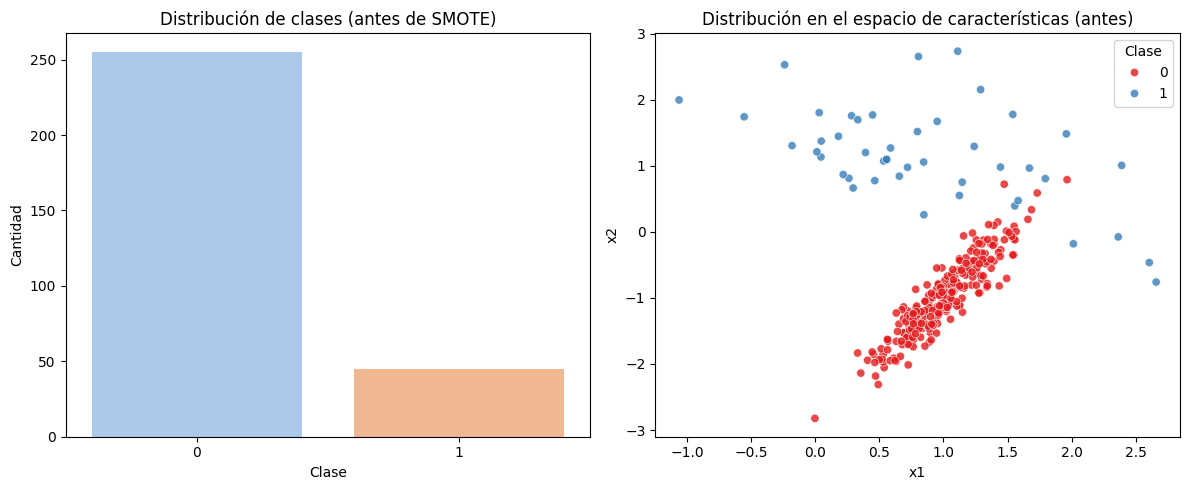

Distribución después de SMOTE: Counter({np.int64(0): 255, np.int64(1): 255})


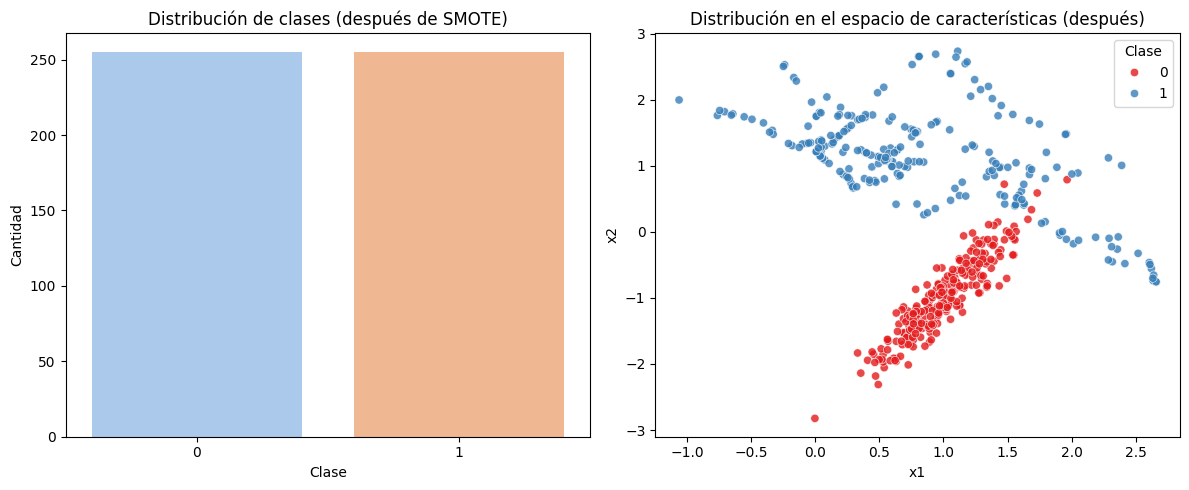

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

# Ejemplo de uso de SMOTE para manejar datos desbalanceados
# Incluye comentarios explicativos y gráficos de la distribución de clases
# (Este cell puede ejecutarse de forma independiente en el notebook.)

import matplotlib.pyplot as plt

# reproducibilidad
RND = 42

# 1) Generar un dataset sintético desbalanceado (2 features para visualización)
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.85, 0.15],  # clase 0 mayoritaria, clase 1 minoritaria
    class_sep=1.0,
    random_state=RND
)

# Mostrar conteo de clases original
print("Distribución original:", Counter(y))

# Convertir a DataFrame para facilitar graficado
df_orig = pd.DataFrame(X, columns=["x1", "x2"])
df_orig["y"] = y

# 2) Visualizaciones antes de SMOTE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x="y", data=df_orig, palette="pastel")
plt.title("Distribución de clases (antes de SMOTE)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.subplot(1, 2, 2)
sns.scatterplot(x="x1", y="x2", hue="y", data=df_orig, palette="Set1", alpha=0.8)
plt.title("Distribución en el espacio de características (antes)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Clase")

plt.tight_layout()
plt.show()

# 3) Aplicar SMOTE para sobremuestrear la clase minoritaria
smote = SMOTE(random_state=RND)
X_res, y_res = smote.fit_resample(X, y)

# Mostrar conteo de clases después de SMOTE
print("Distribución después de SMOTE:", Counter(y_res))

# DataFrame del conjunto re-muestreado
df_res = pd.DataFrame(X_res, columns=["x1", "x2"])
df_res["y"] = y_res

# 4) Visualizaciones después de SMOTE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x="y", data=df_res, palette="pastel")
plt.title("Distribución de clases (después de SMOTE)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.subplot(1, 2, 2)
sns.scatterplot(x="x1", y="x2", hue="y", data=df_res, palette="Set1", alpha=0.8)
plt.title("Distribución en el espacio de características (después)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Clase")

plt.tight_layout()
plt.show()

# 5) Notas rápidas:
# - SMOTE genera ejemplos sintéticos interpolando entre vecinos de la clase minoritaria.
# - Verificar que el sobremuestreo no genere puntos inválidos en problemas con restricciones (por ejemplo, variables categóricas sin codificar).
# - En pipelines reales, aplicar SMOTE solo sobre los datos de entrenamiento (dentro de CV) para evitar fuga de información.


## Selección de Algoritmos y Arquitecturas

La elección del algoritmo de aprendizaje automático es una de las decisiones más críticas en el proceso de optimización, ya que define la capacidad del modelo para capturar patrones en los datos y su eficiencia computacional. Lejos de ser una elección arbitraria, la selección debe basarse en un marco de decisión sistemático que equilibra un conjunto de factores contextuales. Estos factores incluyen el tipo de problema (clasificación, regresión, etc.), el tamaño y las características del dataset (dimensionalidad, tipos mixtos, presencia de datos faltantes), los requisitos de rendimiento (exactitud versus velocidad de inferencia), la necesidad de interpretabilidad (crucial en industrias reguladas como la financiera o la médica) y las restricciones operativas (recursos de memoria, latencia de inferencia en tiempo real). Existen tensiones inherentes que deben ser gestionadas: la dicotomía entre simplicidad y precisión (un modelo lineal simple contra una red neuronal profunda), la rivalidad entre interpretabilidad y rendimiento (un árbol de decisión contra un modelo de ensamble como XGBoost), y el compromiso entre el tiempo de entrenamiento y la calidad de la predicción. Un modelo ganador en un concurso de Kaggle que ofrece un 10% de mejora en precisión pero que es demasiado lento o complejo para ser desplegado en producción puede ser prácticamente inútil, como ilustra el famoso caso del ganador del Netflix Prize.

Históricamente, los **Gradient Boosted Decision Trees** (GBDT) —con modelos como XGBoost, LightGBM y CatBoost— han sido el estándar de oro en el aprendizaje automático tabular, dominando numerosos benchmarks y competiciones. Su éxito se debe a varias fortalezas clave. Son modelos de baja sesgo y alta varianza, lo que les permite capturar patrones complejos y no lineales en los datos. 

Ofrecen una eficiencia computacional superior en comparación con otros modelos de alto rendimiento; por ejemplo, **LightGBM** utiliza una estrategia de crecimiento de árboles "leaf-wise" (vertical) en lugar de "depth-wise" (horizontal) de XGBoost, lo que le permite alcanzar mayor precisión con menos divisiones de nodo, además de incorporar técnicas como Gradient-Based One-Side Sampling (GOSS) y Exclusive Feature Bundling (EFB) para acelerar aún más el entrenamiento. 

**CatBoost** destaca por su manejo nativo de datos categóricos, lo que elimina la necesidad de pre-procesamiento manual y mejora el rendimiento en datasets con muchas variables categóricas. Sin embargo, la era de los GBDTs no es monolítica. LightGBM, por ejemplo, utiliza una estrategia de crecimiento de hoja ("leaf-wise") que puede aumentar el riesgo de sobreajuste si no se controla adecuadamente con hiperparámetros como `max_depth` o `num_leaves`, mientras que la estrategia de nivel ("level-wise") de XGBoost tiende a producir modelos más robustos por defecto.



En los últimos años, el paradigma del aprendizaje tabular ha comenzado a cambiar con el ascenso de las arquitecturas Transformer, tradicionalmente asociadas con el procesamiento del lenguaje natural y el reconocimiento de imágenes. Arquitecturas como FT-Transformer, TabPFN v2 y ModernNCA han demostrado rendimientos competitivos e incluso superiores a los GBDTs en ciertos tipos de datasets. El FT-Transformer, por ejemplo, integra de manera nativa tanto las características numéricas como las categóricas en el mecanismo de atención, lo que le permite capturar interacciones complejas entre todas las variables de entrada. Un benchmark exhaustivo realizado por el repositorio TALENT, que compara más de 30 modelos en 300 datasets, mostró que si bien CatBoost sigue siendo el modelo clásico con el mejor rendimiento promedio, ModernNCA se posiciona como el mejor modelo profundo con un costo computacional aceptable. El análisis comparativo revela una tendencia clara: los GBDTs siguen superando a los Transformers en datasets moderadamente grandes y de alta dimensionalidad (hasta 5,000 características), gracias a su superior eficiencia computacional (5-10 veces más rápido) y manejo nativo de datos mixtos. Sin embargo, los Transformers superan consistentemente a los GBDTs en datasets extremadamente grandes y de alta dimensionalidad (≥10,000 características), donde las interacciones no lineales y contextuales dominan el rendimiento, como en bioinformática o análisis de expresión génica. La elección entre ambos paradigmas, por lo tanto, depende críticamente del tamaño y la naturaleza del dataset. Un modelo como TabPFN v2 representa una tercera vía revolucionaria, demostrando que los modelos de base pre-entrenados pueden resolver problemas tabulares pequeños (<10,000 muestras) en segundos, sin necesidad de ajuste de hiperparámetros, logrando rendimientos superiores a los de XGBoost después de horas de tuning. Esto subraya el futuro del aprendizaje automático tabular, que parece estar evolucionando hacia un enfoque híbrido que aprovecha tanto la flexibilidad y el poder de los Transformers como la eficiencia y robustez de los GBDTs, guiados por benchmarks estandarizados como TALENT.

| Característica | Gradient Boosted Decision Trees (GBDT) | Transformers (FT-Transformer, etc.) | Prior-Data Fitted Networks (PFNs/TabPFN) |
| :--- | :--- | :--- | :--- |
| **Tipo de Modelo** | Ensemble de árboles de decisión débiles. | Redes neuronales basadas en mecanismo de atención. | Redes neuronales pre-entrenadas en distribuciones de datos sintéticas. |
| **Dominio de Aplicación** | Historicamente dominante en tabular data. Excelente en datasets de mediana escala y alta dimensionalidad. | Superior en datasets de muy alta dimensionalidad (≥10k features) y con interacciones no lineales complejas. | Especializado para datasets pequeños (<10k samples, <100 features, <10 clases). |
| **Eficiencia Computacional** | Muy alta. 5-10x más rápido que Transformers en GPUs. LightGBM es particularmente rápido. | Baja. Requiere mucho más tiempo de entrenamiento y consumo de memoria. | Excepcionalmente rápida. Resuelve problemas en segundos o milisegundos. |
| **Manejo de Datos Mixtos** | Nativo. CatBoost maneja categóricos sin one-hot encoding. | Nativo. Integra numéricos y categóricos en embeddings compartidos. | Limitado. TabPFN no maneja datos categóricos nativamente. |
| **Interpretabilidad** | Alta. Métodos robustos como SHAP y feature importance están bien desarrollados. | Baja. Interpretabilidad es un área activa de investigación (ej. mapas de atención). | Muy baja. Funciona como una caja negra. |
| **Flexibilidad** | Menor. Generalmente no se usan para transfer learning. | Alta. Diseñados para transfer learning, meta-learning y uso como extractores de características. |
| **Ejemplos** | XGBoost, LightGBM, CatBoost. | FT-Transformer, TabTransformer, SAINT, ModernNCA. | TabPFN, Do-PFN. |


## Hiperparámetros

### Hiperparámetros en árboles de decisión
Los principales hiperparámetros de un algoritmo de **Árbol de Decisión** incluyen:

1.  **max_depth** (Profundidad máxima del árbol): Este hiperparámetro limita la profundidad máxima del árbol. Si un árbol se vuelve demasiado profundo, puede **sobreajustarse** al conjunto de datos de entrenamiento y perder capacidad de generalización para datos nuevos.

2.  **min_samples_split** (Número mínimo de muestras requeridas para dividir un nodo): Determina el número mínimo de muestras necesarias para que un nodo pueda dividirse. Si la cantidad de muestras en un nodo es inferior al valor establecido, la división no se lleva a cabo.

3.  **min_samples_leaf** (Número mínimo de muestras requeridas para estar en una hoja): Este valor establece la cantidad mínima de muestras requeridas para formar una hoja. Si una división resultara en una hoja con menos muestras que el valor establecido, esa división se descarta.

4.  **max_features** (Número máximo de características a considerar para cada división): Limita el número máximo de características que el algoritmo puede evaluar para cada división. Esto ayuda a **reducir la complejidad** del modelo y mejorar su rendimiento.

5.  **criterion** (Criterio de división): Define el criterio que se utiliza para medir la **calidad de una división**. Los dos criterios más comunes para esta función son **"gini"** y **"entropía"**.

**Índice Gini:**
    *   Es una función de coste utilizada para medir el **"grado de impureza de los nodos"**.
    *   Mide cuán desordenados o mezclados quedan los nodos una vez que se han dividido.
    *   Se utiliza generalmente para atributos con **valores continuos** (como el precio de una casa).
    *   El objetivo del algoritmo es **minimizar ese índice Gini**.

**Entropía:**
    *   Se utiliza para medir la **aleatoriedad o incertidumbre** de un valor aleatorio de una variable.
    *   La entropía es el componente central del criterio de **"Ganancia de información"**, que se utiliza generalmente para atributos **categóricos** (como hombre/mujer).
    *   La Ganancia de información busca **estimar cuánta información aporta cada atributo** a la división.
    *   El objetivo final es **maximizar esa ganancia** de información.

La optimización adecuada de estos hiperparámetros es fundamental para el rendimiento y la precisión del modelo de árbol de decisión.

En el aprendizaje automático, un hiperparámetro es un parámetro que se establece antes del entrenamiento del modelo y **no se aprende directamente de los datos**. Los hiperparámetros influyen en la manera en que los parámetros del modelo se aprenden a partir de los datos, afectando significativamente el rendimiento. Por ejemplo, la profundidad máxima de un árbol de decisión es un ejemplo común de hiperparámetro.



## Optimización de Hiperparámetros

Una vez seleccionado el algoritmo, el siguiente paso crucial en la optimización de modelos es encontrar la configuración óptima de sus hiperparámetros. Los hiperparámetros son configuraciones externas al modelo que se establecen antes del entrenamiento y gobiernan el proceso de aprendizaje en sí mismo; ejemplos comunes incluyen la profundidad máxima de un árbol (`max_depth`), la tasa de aprendizaje (`learning_rate`) o el número de estimadores en un ensemble (`n_estimators`). A diferencia de los parámetros del modelo (como los coeficientes de una regresión lineal), que son aprendidos directamente de los datos, los hiperparámetros definen la estructura y el comportamiento del modelo. Manualmente encontrar la combinación óptima es un proceso iterativo, poco práctico y a menudo subóptimo para modelos complejos con múltiples hiperparámetros. Por lo tanto, se han desarrollado metodologías sistemáticas para automatizar este proceso, con tres enfoques principales destacándose en la literatura y en la práctica profesional: Grid Search (Búsqueda en Grilla), Random Search (Búsqueda Aleatoria) y Bayesian Optimization (Optimización Bayesiana).

### Grid Search

La **Búsqueda en Grilla (Grid Search)** es el método más simple y determinista. Implementado en Scikit-learn como `GridSearchCV`, esta técnica evalúa exhaustivamente todas las posibles combinaciones de hiperparámetros especificadas en una lista de valores. Su principal ventaja es la garantía de encontrar la mejor solución dentro del espacio de búsqueda definido, siempre que dicho espacio contenga la configuración óptima. Sin embargo, esta exhaustividad es también su mayor desventaja: el número de evaluaciones crece exponencialmente con el número de hiperparámetros y el número de valores por hiperparámetro, lo que hace que el método sea computacionalmente prohibitivo para espacios de búsqueda grandes o de alta dimensión. Por ejemplo, una grilla con solo 4 hiperparámetros, cada uno con 3 valores posibles, requeriría 81 evaluaciones del modelo.



`GridSearchCV` realiza una búsqueda exhaustiva sobre un espacio discreto de hiperparámetros, evaluando cada combinación mediante validación cruzada y entregando el mejor conjunto según la métrica especificada.

#### Flujo general
1. Definir un estimador compatible con `fit`.
2. Describir el diccionario `param_grid` donde cada clave es el nombre del hiperparámetro (usando la sintaxis de acceso a atributos, p. ej. `clf__max_depth` dentro de un `Pipeline`) y cada valor es la lista de opciones a evaluar.
3. Ajustar con `fit(X, y)` para ejecutar todas las combinaciones y almacenar métricas en `cv_results_`.
4. Recuperar `best_params_`, `best_estimator_` y `best_score_` para producción o evaluación final.

#### Parámetros principales

| Parámetro | Descripción |
| --- | --- |
| `estimator` | Modelo base a ajustar; puede ser un estimador estándar o un `Pipeline`. |
| `param_grid` | Diccionario (o lista de diccionarios) con las rejillas de hiperparámetros. |
| `scoring` | Métrica usada para comparar combinaciones; acepta string, callable o dict para scoring múltiple. |
| `cv` | Estrategia de validación cruzada (entero para `KFold`, objetos como `StratifiedKFold`, o iterables personalizados). |
| `n_jobs` | Número de procesos en paralelo (`-1` usa todos los núcleos). |
| `verbose` | Nivel de trazas impresas durante la búsqueda. |
| `refit` | Si es `True`, reentrena el estimador final con todo el dataset usando la mejor combinación; también acepta nombre de métrica cuando `scoring` es múltiple. |
| `return_train_score` | Incluye (`True`) o excluye (`False`, por defecto) métricas sobre los folds de entrenamiento en `cv_results_`. |
| `error_score` | Valor asignado a la métrica cuando un ajuste falla (`np.nan` por defecto o `'raise'` para lanzar excepción). |

#### Atributos útiles

- `best_estimator_`: instancia del estimador ya ajustada con la mejor configuración.
- `best_params_`: diccionario de hiperparámetros óptimos.
- `best_score_`: puntuación media obtenida en los folds con la mejor combinación.
- `cv_results_`: diccionario con estadísticas detalladas por combinación (media, desviación estándar, tiempos, etc.).

#### Buenas prácticas

- Reducir el tamaño de la rejilla con conocimiento del dominio para evitar explosión combinatoria.
- Considerar `Pipeline` para encapsular preprocesamiento + modelo, evitando fugas de información.
- Ajustar `cv` de forma estratificada en clasificación desbalanceada.
- Analizar `cv_results_` para inspeccionar sensibilidad a cada hiperparámetro y detectar overfitting.
- Monitorizar `mean_fit_time` y `mean_score_time` para estimar costos computacionales.

In [13]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

# datos sintéticos
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# definición de la rejilla
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejor configuración:", grid.best_params_)
print("Exactitud en test:", grid.score(X_test, y_test))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejor configuración: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Exactitud en test: 0.885


### Random Search
La **Búsqueda Aleatoria (Random Search)** es una alternativa más eficiente computacionalmente. En lugar de probar todas las combinaciones, `RandomizedSearchCV` en Scikit-learn toma una muestra aleatoria de un número especificado de combinaciones de hiperparámetros desde una distribución de probabilidad definida por el usuario. La evidencia empírica respalda consistentemente su superioridad sobre Grid Search en términos de eficiencia. Un estudio comparativo en espacios de búsqueda de 2D, 4D y 6D mostró que Random Search podía ser hasta 24.4 veces más rápido que Grid Search mientras probaba una fracción mucho menor de las configuraciones posibles (desde el 50% en 2D hasta solo el 4.2% en 6D). Sorprendentemente, la pérdida de rendimiento en términos de CV score era mínima (menos del 1%). La intuición detrás de su éxito es que, en muchos problemas, solo unos pocos hiperparámetros tienen un gran impacto en el rendimiento del modelo. Random Search tiene una mayor probabilidad de encontrar buenas configuraciones para estos hiperparámetros clave con menos evaluaciones. Por esta razón, es común usar Random Search como una primera fase para acotar el espacio de búsqueda antes de aplicar una búsqueda más exhaustiva como Grid Search en las regiones más prometedoras.


#### RandomizedSearchCV (scikit-learn)

RandomizedSearchCV realiza una búsqueda aleatoria sobre el espacio de hiperparámetros de un estimador evaluando un número fijo de combinaciones muestreadas desde distribuciones o listas definidas por el usuario. Es una alternativa eficiente a GridSearchCV cuando el espacio de búsqueda es grande y solo unos pocos hiperparámetros influyen significativamente en el rendimiento.

#### Principio de funcionamiento
- En vez de probar todas las combinaciones, se muestrean `n_iter` combinaciones aleatorias.
- Las distribuciones pueden ser listas de valores o distribuciones continuas/discretas (por ejemplo `scipy.stats`), permitiendo muestreo uniforme o según una densidad.
- Se evalúa cada combinación mediante validación cruzada (`cv`) y una métrica (`scoring`).
- Mantiene información de todas las evaluaciones en `cv_results_` y devuelve el mejor estimador según `refit`.

#### Firma principal (resumen)
RandomizedSearchCV(estimator, param_distributions, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', random_state=None, error_score=np.nan, return_train_score=False)

#### Parámetros principales (qué hacen y recomendaciones)
- estimator  
    - Estimador compatible con .fit (p. ej. Pipeline, RandomForestClassifier). No crear nuevas instancias dentro del loop.
- param_distributions  
    - Diccionario {param_name: distribution_or_list}.  
    - Puede contener listas discretas o objetos de `scipy.stats` (p. ej. `scipy.stats.randint`, `scipy.stats.uniform`) para muestreo continuo/discreto.
    - Recomendación: usar distribuciones para hiperparámetros continuos (learning_rate, regularization) y listas para categóricos.
- n_iter (int, por defecto 10)  
    - Número de combinaciones a muestrear. Mayor -> mayor probabilidad de encontrar buen optimo; trade-off con coste.
- scoring  
    - String o callable. Soporta dict para múltiples métricas. Para problemas desbalanceados, preferir `precision`, `recall`, `f1` o `average='binary'`/`'macro'` según contexto.
- n_jobs  
    - Paraleliza evaluaciones (usar `-1` para todos los núcleos). `pre_dispatch` controla cuántos trabajos se envían inicialmente.
- cv  
    - Estrategia de validación cruzada (int o generador como `StratifiedKFold`). En clasificación desbalanceada usar `StratifiedKFold`.
- refit (bool o string)  
    - Si True: reentrena con el conjunto completo usando la mejor combinación encontrada. Si se proporcionan múltiples métricas, `refit` puede ser el nombre de la métrica a optimizar.
- verbose  
    - Nivel de salida por consola (0, 1, 2...). Útil para seguimiento en búsquedas largas.
- random_state  
    - Semilla para reproducibilidad del muestreo aleatorio.
- error_score  
    - Valor devuelto si una evaluación falla (por ejemplo `np.nan` o `'raise'`).
- return_train_score  
    - Incluir/omitir puntuaciones de entrenamiento en `cv_results_`. Útil para diagnosticar overfitting.
- pre_dispatch  
    - Controla la planificación de tareas paralelas (por defecto `'2*n_jobs'`).

#### Atributos útiles tras fit()
- best_params_ : dict con la mejor combinación.
- best_score_ : puntuación media en CV del mejor set de parámetros.
- best_estimator_ : estimador reentrenado (si refit=True).
- cv_results_ : dict con métricas, tiempos, parámetros por trial (útil para análisis y visualización).
- n_splits_ : número efectivo de folds usados.

#### Buenas prácticas y recomendaciones
- Empezar con RandomizedSearchCV para acotar regiones prometedoras; luego refinar con GridSearchCV u Optimización Bayesiana (Optuna) en subespacios reducidos.
- Usar distribuciones continuas para parámetros reales (por ejemplo `log-uniform` para tasas de aprendizaje) y discretas para enteros.
- Definir `cv` estratificado para clasificación con clases desbalanceadas.
- Revisar `cv_results_` para entender sensibilidad a hiperparámetros (mean_test_score, std_test_score, mean_fit_time).
- Si se usan pipelines, referenciar parámetros con la notación `step__param`.
- Fijar `random_state` para reproducibilidad en experimentos comparables.
- Monitorear `mean_fit_time` y `n_iter` para estimar coste computacional y decidir si conviene pruning o early stopping en modelos que lo soporten.

#### Interpretación y análisis de resultados
- Ordenar `cv_results_['mean_test_score']` para ver la distribución del rendimiento por trial y detectar estabilidad (`std_test_score`).
- Si el mejor resultado tiene alta varianza entre folds, considerar aumentar CV folds o recolectar más datos.
- Comparar `best_estimator_` reentrenado frente a un baseline (validación hold-out) antes de desplegar.

**Resumen**: **RandomizedSearchCV** es una herramienta flexible y eficiente para exploración de hiperparámetros cuando el espacio es grande; combinarlo con buenas elecciones de distribuciones, CV estratificado y análisis cuidadoso de `cv_results_` mejora tanto la eficiencia como la robustez de la búsqueda.

In [14]:
# random search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": randint(2, 11),   # ejemplo de distribución discreta
        "min_samples_leaf": randint(1, 5)
}

rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_distributions=param_dist,
        n_iter=30,
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=False,
        refit=True
)

rs.fit(X_train, y_train)

print(rs.best_params_, rs.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200} 0.89375


### Optimizacion Bayesiana
La **Optimización Bayesiana (Bayesian Optimization, BO)** representa el estado del arte en la optimización de hiperparámetros y es significativamente más inteligente y eficiente que los métodos anteriores. A diferencia de Grid y Random Search, que no retienen información de evaluaciones previas, la Optimización Bayesiana utiliza un modelo probabilístico, llamado "modelo sustituto" (surrogate model, a menudo un Proceso Gaussiano), para modelar la función objetivo (por ejemplo, el error de validación del modelo) como una función de los hiperparámetros. Este modelo aprende de cada evaluación anterior para construir una creencia sobre dónde podría estar el óptimo global. Simultáneamente, utiliza una "función de adquisición" (acquisition function, como Expected Improvement o Upper Confidence Bound) para decidir inteligentemente dónde evaluar el próximo conjunto de hiperparámetros, buscando explícitamente un equilibrio entre la exploración (explorar regiones de alta incertidumbre) y la explotación (explorar regiones que se sabe que son buenas). Como resultado, converge a la configuración óptima con un número drásticamente menor de evaluaciones del modelo. Una comparación directa en un conjunto de datos de Kaggle mostró que tanto `bayes_opt` como `hyperopt` alcanzaron el mejor rendimiento en aproximadamente 20 minutos, mientras que Grid Search tardó 5400 veces más tiempo en evaluar todas las combinaciones. 

Para implementar la Optimización Bayesiana, frameworks como **Optuna** y **Ray Tune** son herramientas de nivel profesional. Optuna es particularmente poderoso por su capacidad de definir espacios de búsqueda condicionales (donde la elección de un hiperparámetro depende de otro) y su soporte nativo para pruebas automáticas (pruning), como ASHA o MedianStoppingRule, que terminan prematuramente los experimentos que no muestran un rendimiento prometedor, ahorrando recursos computacionales significativos. 

En resumen, para un trabajo de investigación avanzado, la Optimización Bayesiana es la metodología preferida, y su implementación con herramientas modernas como Optuna es una habilidad esencial para cualquier científico de datos.



La Optimización Bayesiana es una estrategia para optimizar funciones costosas de evaluar (por ejemplo, la métrica de validación de un modelo) cuando cada evaluación requiere entrenamiento y validación. BO construye un modelo probabilístico (surrogate) de la función objetivo y utiliza una función de adquisición para decidir de forma inteligente qué punto evaluar a continuación, equilibrando exploración (regiones con alta incertidumbre) y explotación (regiones con buena media esperada).

#### Principales componentes
- Surrogate model (modelo sustituto)
    - Modela la función objetivo p(f(x) | D). Ejemplos: Proceso Gaussiano (GP), Random Forests, TPE (Tree-structured Parzen Estimator).
    - Proporciona predicción de media y varianza en cualquier x.
- Acquisition function (función de adquisición)
    - Decide el próximo x a evaluar maximizando una utilidad calculada sobre la distribución predictiva.
    - Ejemplos: Expected Improvement (EI), Probability of Improvement (PI), Upper Confidence Bound (UCB).
- Evaluaciones (trials)
    - Cada trial evalúa la métrica real (p. ej. error CV) en una configuración de hiperparámetros y se añade a D.
- Pruning / early stopping
    - Permite detener trials prometedores con bajo rendimiento temprano para ahorrar tiempo (p. ej. Median/Successive Halving).

#### Parámetros y conceptos clave
- space / search space: dominio de hiperparámetros (continuos, discretos, categóricos, condicionales).
- n_trials / timeout: número máximo de evaluaciones o tiempo total.
- direction: 'minimize' o 'maximize' según la métrica.
- sampler: algoritmo para construir la posterior (GP, TPE/TreeParzen). Ej. Optuna usa TPE por defecto.
- acquisition function: EI/PI/UCB (configurable en algunos frameworks).
- n_startup_trials: número de evaluaciones aleatorias iniciales para construir el surrogate.
- pruning: activación y estrategia (MedianPruner, SuccessiveHalving).
- n_jobs / parallelización: ejecución paralela asíncrona/síncrona de trials (cuidado con samplers dependientes).
- random_state / seed: reproducibilidad.

#### Ventajas
- Evalúa muchas menos configuraciones que Grid/Random Search.
- Muy útil para espacios costosos y de alta dimensionalidad con evaluaciones caras.
- Soporta espacios condicionales y pruning para ahorrar recursos.

#### Limitaciones y consideraciones prácticas
- Las evaluaciones deben ser lo suficientemente informativas (ruido alto reduce la eficiencia).
- GP no escala bien con muchísimos trials; usar TPE o surrogates no-GP en esos casos.
- Paralelizar reduce eficiencia del proceso secuencial de BO; usar estrategias asíncronas o múltiples inicializaciones.
- Diseñar bien el espacio de búsqueda (transformaciones log, límites adecuados) mejora resultados.
- Monitorizar diagnósticos (historial de trials) y validar en hold-out final para evitar overfitting en la búsqueda.

#### Buenas prácticas
- Normalizar/transformar hiperparámetros continuos (log-scale para learning rate).
- Incluir evaluaciones aleatorias iniciales.
- Usar pruning si los modelos soportan checkpoints o evaluación intermedia.
- Limitar n_trials según coste y usar nested CV si se necesita estimación sin sesgo.
- Reentrenar el mejor conjunto en todo el training set antes de evaluar en test.


In [15]:
# Ejemplo: optimización bayesiana con Optuna sobre RandomForestClassifier
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def objective(trial):
        # espacio de búsqueda
        params = {
                "n_estimators": trial.suggest_categorical("n_estimators", [50, 100, 200]),
                "max_depth": trial.suggest_categorical("max_depth", [None, 5, 10, 20]),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
                "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
        }

        clf = RandomForestClassifier(random_state=42, **params)

        # evaluación robusta: K-Fold estratificado
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
        # Optuna maximiza, así que devolvemos la media de scores
        return float(np.mean(scores))

# Crear estudio: TPE (Tree-structured Parzen Estimator) y pruner para early stopping
study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)
)

# Ejecutar optimización (por ejemplo 50 trials)
study.optimize(objective, n_trials=10, timeout=None, n_jobs=1)

print("Mejor score CV:", study.best_value)
print("Mejores hiperparámetros:", study.best_params)

# Reentrenar mejor modelo en todo X_train y evaluar en X_test
best_params = study.best_params.copy()
best_clf = RandomForestClassifier(random_state=42, **best_params)
best_clf.fit(X_train, y_train)
print("Exactitud en test:", best_clf.score(X_test, y_test))


[I 2025-12-11 02:38:34,325] A new study created in memory with name: no-name-6374195d-800d-4681-863e-4647c0e2fdb2
[I 2025-12-11 02:38:34,583] Trial 0 finished with value: 0.8962715778209569 and parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.8962715778209569.
[I 2025-12-11 02:38:35,466] Trial 1 finished with value: 0.8687871363802765 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.8962715778209569.
[I 2025-12-11 02:38:35,723] Trial 2 finished with value: 0.8875231149033632 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.8962715778209569.
[I 2025-12-11 02:38:35,879] Trial 3 finished with value: 0.8887668609726563 

Mejor score CV: 0.8962715778209569
Mejores hiperparámetros: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}
Exactitud en test: 0.905


### Particle Swarm Optimization (PSO)

Particle Swarm Optimization (PSO) es un método metaheurístico inspirado en el comportamiento social de bandadas o cardúmenes. Cada partícula representa una posible solución (vector de parámetros). Las partículas se mueven en el espacio de búsqueda actualizando su velocidad según:
- inercia (mantener parte del movimiento previo),
- componente cognitiva (atracción hacia la mejor solución encontrada por la partícula),
- componente social (atracción hacia la mejor solución global).

PSO resulta útil para optimizar hiperparámetros cuando el espacio es ruidoso o no conviene derivar gradientes. A continuación hay un ejemplo práctico que usa PSO para optimizar hiperparámetros de un RandomForest sobre los datos ya presentes en este notebook. Se muestra la distribución de clases verdaderas y las predichas por un modelo por defecto ("antes") y por el modelo afinado con PSO ("después").



PSO: inicio. Mejor score inicial (CV f1_macro): 0.8874
Iter 1/15 - Mejor CV f1_macro: 0.8911
Iter 5/15 - Mejor CV f1_macro: 0.8911
Iter 10/15 - Mejor CV f1_macro: 0.8936
Iter 15/15 - Mejor CV f1_macro: 0.8936
Mejores hiperparámetros encontrados por PSO: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 2}
Mejor CV f1_macro: 0.8936493735613952

Métricas (test):
Default - accuracy: 0.900, f1_macro: 0.900
PSO    - accuracy: 0.905, f1_macro: 0.905


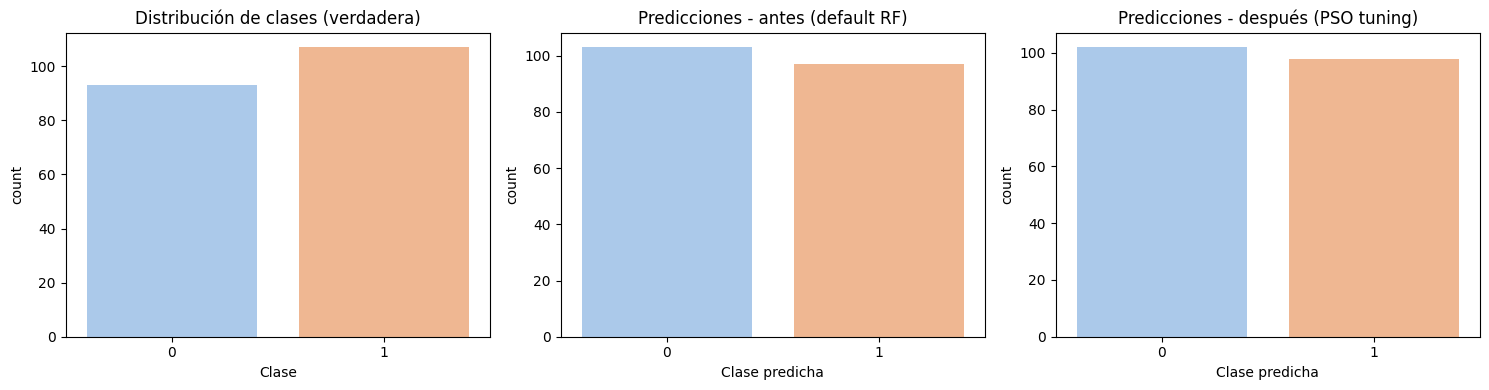

In [18]:

# Implementación demostrativa de PSO para ajuste de hiperparámetros de RandomForest
# Usa variables ya definidas en este notebook: X_train, y_train, X_test, y_test, RND, RandomForestClassifier, StratifiedKFold
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuración PSO (parámetros demostrativos, reducir para prueba rápida) ---
n_particles = 20
n_iterations = 15
w = 0.7   # inercia
c1 = 1.5  # coef. cognitivo
c2 = 1.5  # coef. social
rng = np.random.RandomState(RND)

# Definir límites de hiperparámetros: (min, max)
bounds = {
    "n_estimators": (10, 300),
    "max_depth": (1, 50),            # usaremos 0 para None si lo consideramos
    "min_samples_split": (2, 20),
    "min_samples_leaf": (1, 10)
}
param_names = list(bounds.keys())
dim = len(param_names)

# Utilidad: convierte posición continua en hiperparámetros discretos válidos
def pos_to_params(pos):
    # pos: array de dimensión dim, valores en [0,1]
    params = {}
    for i, name in enumerate(param_names):
        lo, hi = bounds[name]
        val = lo + pos[i] * (hi - lo)
        if name in ("n_estimators", "min_samples_split", "min_samples_leaf"):
            params[name] = int(round(val))
            params[name] = max(1, params[name])
        elif name == "max_depth":
            # aleatoriamente permitir None si pos muy cerca de 0
            depth = int(round(val))
            params[name] = None if depth <= 1 else int(depth)
    return params

# Función objetivo: CV estratificado con F1 (puede ajustarse)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RND)
def fitness_from_pos(pos):
    params = pos_to_params(pos)
    clf = RandomForestClassifier(random_state=RND, **params)
    # usamos f1 (macro) para balancear clases, cambiar si se prefiere otra métrica
    try:
        scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
        return float(np.mean(scores))
    except Exception:
        return 0.0

# --- Inicializar partículas ---
# posiciones en [0,1]^dim, velocidades pequeñas
positions = rng.rand(n_particles, dim)
velocities = rng.uniform(-0.1, 0.1, size=(n_particles, dim))
pbest_pos = positions.copy()
pbest_score = np.array([fitness_from_pos(p) for p in positions])
gbest_idx = int(np.argmax(pbest_score))
gbest_pos = pbest_pos[gbest_idx].copy()
gbest_score = pbest_score[gbest_idx]

# Registro breve de progreso
print("PSO: inicio. Mejor score inicial (CV f1_macro): {:.4f}".format(gbest_score))

# --- Bucle PSO ---
for it in range(n_iterations):
    for i in range(n_particles):
        r1 = rng.rand(dim)
        r2 = rng.rand(dim)
        # actualizar velocidad y posición
        velocities[i] = (w * velocities[i]
                         + c1 * r1 * (pbest_pos[i] - positions[i])
                         + c2 * r2 * (gbest_pos - positions[i]))
        positions[i] = positions[i] + velocities[i]
        # mantener en [0,1]
        positions[i] = np.clip(positions[i], 0.0, 1.0)
        # evaluar
        score = fitness_from_pos(positions[i])
        if score > pbest_score[i]:
            pbest_score[i] = score
            pbest_pos[i] = positions[i].copy()
            # actualizar global
            if score > gbest_score:
                gbest_score = score
                gbest_pos = positions[i].copy()
    if (it + 1) % 5 == 0 or it == 0:
        print(f"Iter {it+1}/{n_iterations} - Mejor CV f1_macro: {gbest_score:.4f}")

# Obtener mejores hiperparámetros
best_params_pso = pos_to_params(gbest_pos)
print("Mejores hiperparámetros encontrados por PSO:", best_params_pso)
print("Mejor CV f1_macro:", gbest_score)

# --- Entrenar clasificadores: antes (default) y después (PSO) ---
clf_default = RandomForestClassifier(random_state=RND)
clf_default.fit(X_train, y_train)
pred_before = clf_default.predict(X_test)

clf_pso = RandomForestClassifier(random_state=RND, **best_params_pso)
clf_pso.fit(X_train, y_train)
pred_after = clf_pso.predict(X_test)

# Métricas resumidas
print("\nMétricas (test):")
print("Default - accuracy: {:.3f}, f1_macro: {:.3f}".format(
    accuracy_score(y_test, pred_before), f1_score(y_test, pred_before, average="macro")))
print("PSO    - accuracy: {:.3f}, f1_macro: {:.3f}".format(
    accuracy_score(y_test, pred_after), f1_score(y_test, pred_after, average="macro")))

# --- Gráficos distribución de clases: verdadera vs predicha antes/después ---
import pandas as pd

df_plot = pd.DataFrame({
    "true": y_test,
    "pred_before": pred_before,
    "pred_after": pred_after
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="true", data=df_plot, palette="pastel", ax=axes[0])
axes[0].set_title("Distribución de clases (verdadera)")
axes[0].set_xlabel("Clase")

sns.countplot(x="pred_before", data=df_plot, palette="pastel", ax=axes[1])
axes[1].set_title("Predicciones - antes (default RF)")
axes[1].set_xlabel("Clase predicha")

sns.countplot(x="pred_after", data=df_plot, palette="pastel", ax=axes[2])
axes[2].set_title("Predicciones - después (PSO tuning)")
axes[2].set_xlabel("Clase predicha")

plt.tight_layout()
plt.show()


Notas rápidas y recomendaciones
- El PSO mostrado es educativo y de propósito demostrativo; para producción ajustar hyperparámetros del PSO (tamaño de enjambre, iteraciones, coeficientes) y usar validación anidada si se requiere estimación sin sesgo.
- PSO puede consumir tiempo porque evalúa modelos repetidamente; usar n_jobs, CV con menos folds o subsets para prototipado.
- En problemas de clases desbalanceadas, optimizar la métrica adecuada (por ejemplo F1 macro, PR-AUC) es crítico para evitar soluciones que favorezcan la clase mayoritaria.


### Variantes y herramientas alternativas
- scikit-optimize (skopt): GP-based BO simple.
- Hyperopt: usa TPE (similar a Optuna).
- Ax (Facebook) + BoTorch: BO avanzada con GP y GPU.
- Ray Tune: escalado y orchestration de optimización (soporta BO, ASHA, etc.).

Resumen: la Optimización Bayesiana aprende de evaluaciones previas para seleccionar nuevas configuraciones prometedoras, reduciendo el número de entrenamientos necesarios. Para la práctica, usar frameworks como Optuna o Ax, diseñar adecuadamente el espacio de búsqueda, habilitar pruning y validar cuidadosamente el mejor modelo final.


| Método de Optimización de Hiperparámetros | Principio Básico | Eficiencia Computacional | Exhaustividad | Mejor Uso |
| :--- | :--- | :--- | :--- | :--- |
| **Grid Search** | Evalúa todas las combinaciones de hiperparámetros en una grilla predefinida. | Muy baja. Escala exponencialmente con el número de hiperparámetros y valores. | Alta. Garantiza encontrar la mejor solución dentro de la grilla especificada. | Espacios de búsqueda pequeños y bien acotados donde se quiere una búsqueda exhaustiva. |
| **Random Search** | Muestra aleatoriamente combinaciones de hiperparámetros de una distribución. | Alta. Significativamente más rápida que Grid Search, especialmente en espacios de alta dimensión. | Baja. No garantiza encontrar la mejor solución. | Acotar el espacio de búsqueda inicialmente o cuando el espacio es muy grande para que Grid Search sea inviable. |
| **Bayesian Optimization** | Usa un modelo probabilístico para modelar la función objetivo y decide dónde evaluar el siguiente punto. | Muy alta. Requiere un número mínimo de evaluaciones para converger a la solución óptima. | Media. No es exhaustivo, pero es muy probable que encuentre el óptimo global. | Problemas de optimización costosos computacionalmente, espacios de búsqueda grandes y de alta dimensión. |

## Visualización y Diagnóstico Avanzado

La optimización de modelos es un proceso experimental que requiere una interpretación profunda y continua del rendimiento del modelo en curso. La presentación de métricas numéricas por sí sola es insuficiente; la visualización es una herramienta indispensable para diagnosticar problemas subyacentes como el sobreajuste (overfitting), el subajuste (underfitting) y las debilidades en la capacidad predictiva del modelo. Un conjunto de visualizadores modernos, integrados en librerías como Scikit-Learn y Yellowbrick, permite a los científicos de datos pasar de una comprensión abstracta a una intuición visual del comportamiento del modelo, facilitando decisiones de optimización más informadas. Estos gráficos no solo comunican resultados, sino que también revelan patrones ocultos en los datos y el modelo, guiando la ingeniería de características, la selección de algoritmos y la sintonización de hiperparámetros.

Un conjunto de visualizadores clave para el diagnóstico de modelos supervisados incluye aquellos diseñados para evaluar la calibración y la discriminación de un clasificador. La `ConfusionMatrixDisplay` muestra una tabla de contingencia que resume el rendimiento del modelo, permitiendo identificar fácilmente dónde está cometiendo errores (errores de falsos positivos y falsos negativos). Para los modelos que emiten probabilidades, `CalibrationDisplay` es crucial para verificar si las probabilidades predichas son fiables; un buen modelo debería tener sus puntos de calibración cerca de la línea diagonal ideal, indicando que un evento con una probabilidad del 80% realmente ocurre el 80% de las veces. Para los modelos binarios, la `RocCurveDisplay` y la `PrecisionRecallDisplay` son las herramientas estándar para evaluar la capacidad de discriminación. Como se discutió anteriormente, la curva ROC (TPR vs. FPR) es sensible a la distribución de clases, mientras que la curva PR (precisión vs. recall) es más informativa para datasets desbalanceados. El `DetCurveDisplay` ofrece una variante de la curva ROC que usa un eje de coordenadas normalizado, lo que facilita la comparación entre modelos. Para los modelos de regresión, `PredictionErrorDisplay` crea un gráfico de dispersión de los valores reales versus los predichos, donde una línea de identidad perfecta indica un rendimiento ideal.

Además de la evaluación general del modelo, la visualización juega un papel vital en la comprensión de la influencia de las características. Los visualizadores de Yellowbrick como `RankFeatures` (`Rank1D` y `Rank2D`) proporcionan una vista rápida de la importancia relativa de cada característica, ya sea individualmente o en pares, ayudando a identificar las variables más predictivas. La `DecisionBoundaryDisplay` es una herramienta poderosa para modelos de clasificación, ya que visualiza gráficamente el límite de decisión que el modelo ha aprendido, pintando regiones de color según la clase predicha. Esto es especialmente útil para visualizar cómo un modelo no lineal como un SVM con kernel RBF o una red neuronal está separando las clases en el espacio de características. La `PartialDependenceDisplay` muestra la dependencia parcial de la salida del modelo en una o dos características, manteniendo otras constantes, lo que ayuda a entender cómo una característica afecta la predicción independientemente de las demás.

Finalmente, para guiar el proceso de optimización de hiperparámetros, las curvas de validación y las curvas de aprendizaje son indispensables. El visualizador `ValidationCurveDisplay` de Scikit-Learn permite visualizar cómo el rendimiento del modelo cambia a medida que se varía un único hiperparámetro, mostrando las puntuaciones de entrenamiento y validación cruzada. Analizando esta curva, se puede identificar si un modelo sufre de subajuste (rendimiento bajo en ambos conjuntos) o sobreajuste (gran separación entre los rendimientos de entrenamiento y validación) y determinar el valor óptimo para ese hiperparámetro. Por ejemplo, al graficar la precisión en función del número de estimadores (`n_estimators`) en un Gradient Boosting, se puede observar cómo el rendimiento mejora inicialmente pero luego se estanca o incluso disminuye, revelando el punto de saturación. De manera similar, el `LearningCurveDisplay` muestra cómo el rendimiento del modelo cambia a medida que aumenta el tamaño del conjunto de entrenamiento, ayudando a diagnosticar si el modelo podría beneficiarse de más datos o si necesita ser más complejo. Si las curvas de aprendizaje del entrenamiento y la validación se estabilizan en un rendimiento relativamente bajo, el problema probablemente no sea el sobreajuste, sino un subajuste fundamental. Por el contrario, si existe una brecha significativa entre las dos curvas, el modelo está sobreajustando y podría beneficiarse de más datos o una mayor regularización. Estas visualizaciones proporcionan una retroalimentación instantánea que acelera drásticamente el ciclo de iteración en la optimización de modelos.

| Visualizador | Objetivo Principal | Qué Revela | Librería Base |
| :--- | :--- | :--- | :--- |
| **ConfusionMatrixDisplay** | Evaluación de Clasificación | Distribución de errores de clasificación (TP, TN, FP, FN). | Scikit-Learn |
| **CalibrationDisplay** | Calibración de Probabilidades | Fidelidad de las probabilidades predichas. | Scikit-Learn |
| **RocCurveDisplay / PrecisionRecallDisplay** | Discriminación | Capacidad del modelo para distinguir entre clases. PR es preferible para datasets desbalanceados. | Scikit-Learn |
| **DecisionBoundaryDisplay** | Visualización de Límites de Decisión | Regiones de decisión del clasificador en un espacio 2D. | Scikit-Learn  |
| **RankFeatures (Rank1D/2D)** | Importancia de Características | Jerarquía de importancia de características. | Yellowbrick [[11](https://www.scikit-yb.org/)] |
| **ValidationCurveDisplay** | Tuning de Hiperparámetros | Efecto de un hiperparámetro en el rendimiento de entrenamiento y validación. | Scikit-Learn |
| **LearningCurveDisplay** | Diagnóstico de Rendimiento | Relación entre el rendimiento del modelo y la cantidad de datos de entrenamiento. | Scikit-Learn  |
| **PartialDependenceDisplay** | Dependencia Parcial | Efecto marginal de una o dos características en la predicción. | Scikit-Learn  |

### ValidationCurveDisplay


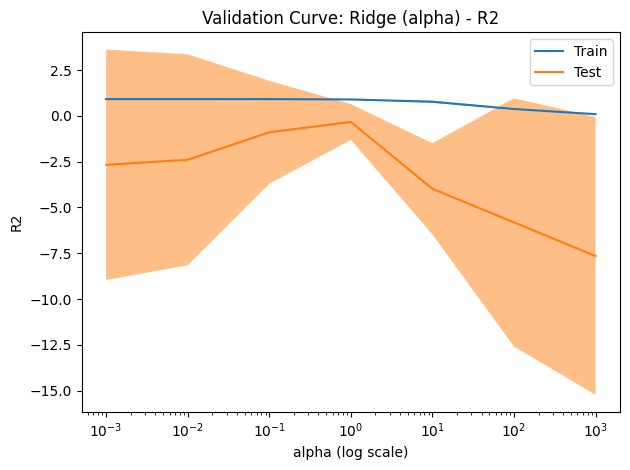

In [22]:
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.linear_model import Ridge

# Ejemplo autocontenido de ValidationCurveDisplay (usa X, y ya definidos en el notebook)

# Pipeline reutilizando make_pipeline, PolynomialFeatures y StandardScaler ya disponibles
pipe = make_pipeline(
    PolynomialFeatures(degree=5, include_bias=False),
    StandardScaler(),
    Ridge(random_state=42)
)

# Rango del hiperparámetro a explorar (alpha de Ridge) en escala log
param_range = np.logspace(-3, 3, 7)

# Dibujar la Validation Curve (muestra score de entrenamiento y validación CV)
disp = ValidationCurveDisplay.from_estimator(
    pipe,
    X, y,
    param_name="ridge__alpha",
    param_range=param_range,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

import matplotlib.pyplot as plt
plt.title("Validation Curve: Ridge (alpha) - R2")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.tight_layout()
plt.show()

Interpretación del Validation Curve (Ridge alpha, scoring=r2):

- Ejes
    - X: valor de alpha (escala log). A la izquierda = poca regularización; a la derecha = mucha regularización.
    - Y: R² (score). Hay dos curvas: entrenamiento (train) y validación (CV).

- Qué buscar
    - Overfitting: alta puntuación en training y mucho menor en validación (gran brecha). Suele ocurrir con alpha muy pequeño (poca regularización).
    - Underfitting: puntuaciones bajas en ambos (train y validación) cuando alpha es muy grande (exceso de regularización).
    - Zona óptima: rango de alpha donde la curva de validación alcanza su máximo y la brecha con training es razonablemente pequeña. Ese es el valor candidato para alpha.

- Estabilidad y confianza
    - Si las curvas tienen mucha variación entre folds (altas barras de error / std), la elección es inestable: aumentar folds o datos, o usar búsqueda más robusta (Grid/Random/Optuna).
    - Preferir valores de alpha dentro de una región plana cerca del máximo de validación (más robusto) en vez de un pico muy estrecho.

- Pasos prácticos siguientes
    1. Extraer medias y desviaciones de train/test para el parámetro y localizar el índice del mejor score de validación.
    2. Reentrenar el modelo con ese alpha sobre todo el training y evaluar en test independiente.
    3. Si se requiere mayor precisión, hacer GridSearchCV/RandomizedSearchCV/Optuna alrededor de la región prometedora (usar escala log).


In [24]:
# Código para extraer el mejor alpha desde validation_curve:

from sklearn.model_selection import validation_curve
import numpy as np

param_range = np.logspace(-3, 3, 7)
train_scores, test_scores = validation_curve(pipe, X, y, param_name="ridge__alpha",
                            param_range=param_range, cv=5, scoring="r2", n_jobs=-1)
train_mean = train_scores.mean(1)
test_mean = test_scores.mean(1)
best_idx = np.argmax(test_mean)
best_alpha = param_range[best_idx]
print("Mejor alpha (CV):", best_alpha, "CV R2:", test_mean[best_idx])

Mejor alpha (CV): 1.0 CV R2: -0.33372945701733564


## Sobreajustes (Overfitting)

La sobreajuste (overfitting) ocurre cuando un modelo de aprendizaje automático (Machine Learning) se ajusta demasiado cerca a los detalles y al ruido en el conjunto de datos de entrenamiento, hasta el punto de que su capacidad para generalizar a datos nuevos o invisibles se ve afectada negativamente.

En esencia, el modelo memoriza los casos particulares y sus defectos (incluyendo ruido o distorsión) del conjunto de entrenamiento en lugar de aprender el patrón subyacente. Un modelo sobreajustado puede mostrar un error muy bajo (o una precisión alta) en el conjunto de entrenamiento, pero un error significativamente mayor en el conjunto de prueba (test).

Causas del Sobreajuste:

El sobreajuste ocurre generalmente cuando el modelo es demasiado complejo para la cantidad de información disponible, o cuando el entrenamiento es excesivo ("sobreentrenamiento"). Específicamente:

• Modelos demasiado complejos: Sucede con modelos no paramétricos y no lineales que tienen mucha flexibilidad, como los árboles de decisión que tienen una profundidad suficiente o las redes neuronales con demasiadas capas ocultas.

• Datos insuficientes o con ruido: Si la cantidad de datos de entrenamiento es muy limitada o contienen ruido/distorsión, el modelo puede terminar memorizando las peculiaridades de esas pocas muestras.

• Dimensionalidad excesiva: Un número excesivo de características (features) en el conjunto de datos, sin suficientes muestras, aumenta la complejidad y el riesgo de sobreajuste (fenómeno conocido como la "maldición de la dimensionalidad").

### Soluciones para Corregir y Prevenir el Sobreajuste

La **Regularización** es una técnica utilizada para **disminuir el nivel de sobreajuste de un modelo**. Su propósito es **atenuar la magnitud de los parámetros** de forma que el modelo sea menos sensible a los datos de entrenamiento y pueda tener una **mejor capacidad de generalización**. Un modelo regularizado exhibe un **menor error de varianza** y, por lo tanto, una **mejor generalización** en comparación con un modelo sobreajustado.

La regularización se lleva a cabo añadiendo un **término adicional a la función de costo** original del modelo.

#### Tipos de Regularización

**1. Regularización (Atenuación de la complejidad del modelo)**

Las dos técnicas de regularización más comunes son:

- **Regularización L2 (Ridge Regression):** Penaliza la función de costo con un término adicional equivalente a la **suma de los cuadrados de los coeficientes**. Esta técnica se implementa en la **Regresión Ridge**.
    *   La función de costo resultante es: RSS + $\alpha$ \* (suma del cuadrado de los coeficientes).

- **Regularización L1 (Lasso Regression):** Penaliza la función de costo con un término adicional equivalente a la **suma de los valores absolutos de los coeficientes**. Esta técnica se implementa en la **Regresión Lasso**.
    *   La función de costo resultante es: RSS + $\alpha$ \* (suma de los valores absolutos de los coeficientes).

Tanto la Regresión Lasso como la Regresión Ridge son ejemplos de **métodos embebidos** que utilizan algoritmos con métodos de selección de características incorporados.

*   Un modelo sin regularización (como el ajuste con regresión polinomial y OLS) puede mostrar un **sobreajuste** evidente.
*   Al aplicar la **Regresión Ridge** (que utiliza la regularización L2 con un parámetro $\alpha=0.001$), se obtiene un ajuste suavizado que conduce a una curva menos volátil y con una **mejor generalización**.

**2. Reducción de la Complejidad del Modelo/Algoritmo**

Se puede limitar la complejidad intrínseca del modelo:
- Ajuste de Hiperparámetros (Tuning): Consiste en encontrar los valores óptimos de los hiperparámetros (parámetros que no se aprenden de los datos y se configuran antes del entrenamiento) para reducir la complejidad. Ejemplos específicos incluyen:
    - Árboles de Decisión: Limitar la profundidad máxima del árbol (max_depth) o aumentar el número mínimo de muestras requeridas para una división (min_samples_split o min_samples_leaf) evita que el árbol memorice los detalles.
    - Redes Neuronales: Reducir el número de capas ocultas o neuronas, o aplicar técnicas como Dropout.
-  Uso de Modelos de Ensamble (Random Forest): Los bosques aleatorios (Random Forest) son intrínsecamente más robustos al sobreajuste que un solo árbol de decisión

**3. Manejo de Datos**

Las estrategias relacionadas con los datos incluyen:
- Validación Cruzada (Cross-Validation): Es una técnica robusta de evaluación que particiona el conjunto de datos de entrenamiento en múltiples subconjuntos (folds). Permite estimar el rendimiento del modelo en datos no vistos (generalización) de manera más confiable y ayuda a evitar el sobreajuste.

- Aumento de Muestras: Aumentar la cantidad y diversidad de los datos de entrenamiento para proporcionar al modelo más ejemplos para aprender y capturar la variabilidad inherente en el problema, mejorando así la generalización.

- Selección de Características (Feature Selection): Eliminar características (variables de entrada) irrelevantes o redundantes que añaden ruido, lo que puede reducir la complejidad del modelo y aumentar su precisión.

- Ingeniería de Características (Feature Engineering): Crear y seleccionar nuevas variables que sean más relevantes para la tarea en cuestión, lo que también puede ayudar a reducir el sobreajuste.

- División de Datos: Usar un conjunto de prueba (test) independiente para evaluar el rendimiento. La evaluación en este conjunto, que el modelo nunca vio, es crucial para evitar el sobreajuste y obtener una estimación realista del rendimiento.

El sobreajuste es como un estudiante que memoriza cada línea de un libro de texto (incluyendo los errores tipográficos) para un examen, obteniendo una puntuación perfecta en ese material específico, pero fallando en cualquier pregunta que requiera aplicar el concepto o usar información fuera de ese libro. La regularización, en este caso, sería forzar al estudiante a resumir y priorizar los conceptos clave, asegurando una comprensión más amplia y general.

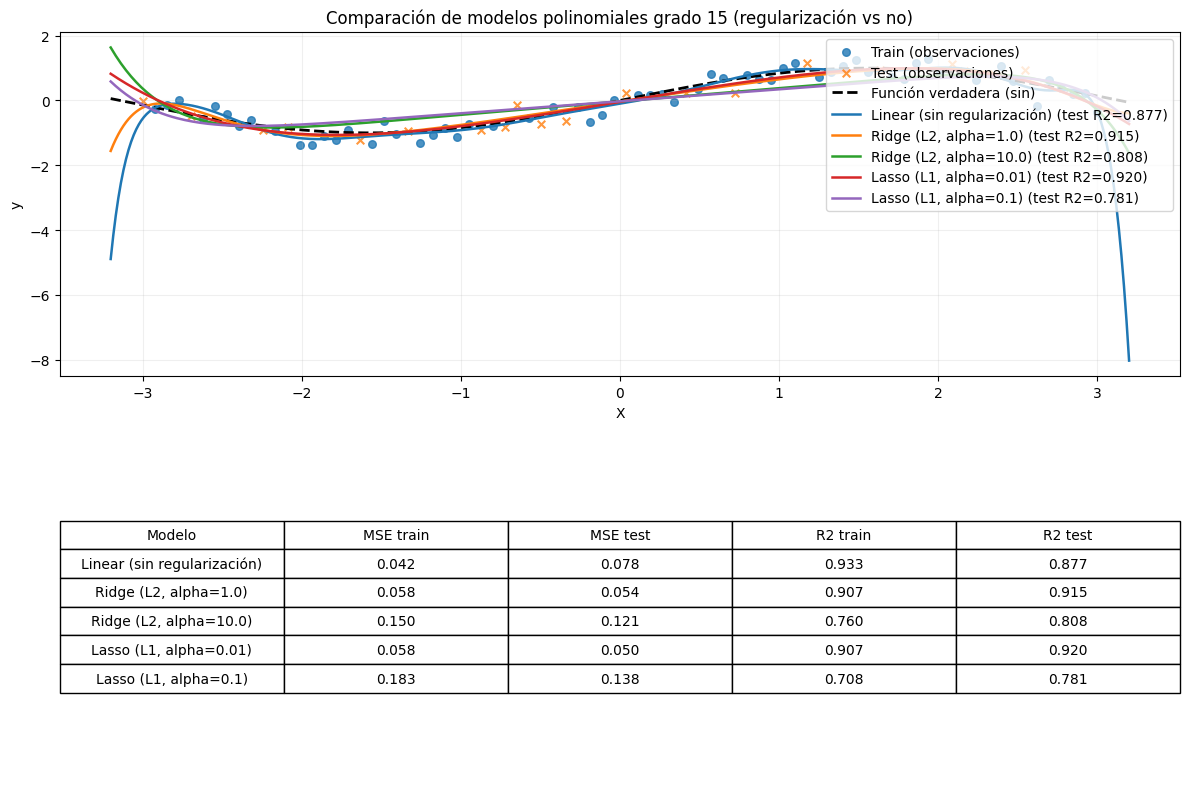

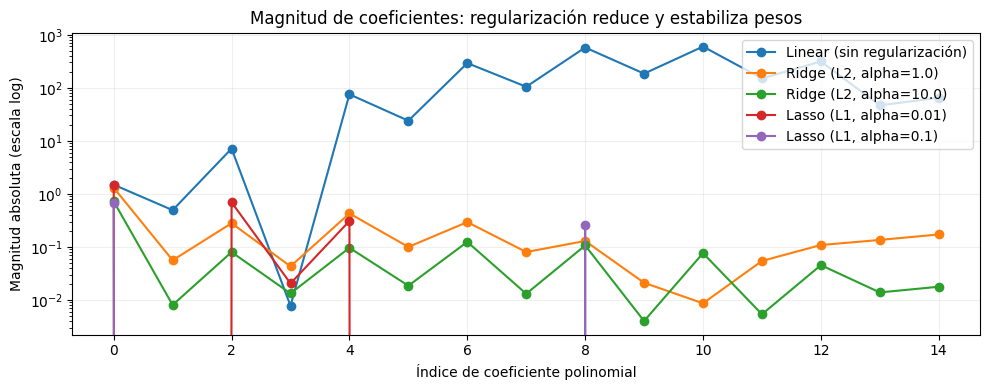

Resumen de métricas (MSE test y R2 test):
- Linear (sin regularización): MSE_test=0.0777, R2_test=0.8767
- Ridge (L2, alpha=1.0): MSE_test=0.0536, R2_test=0.9149
- Ridge (L2, alpha=10.0): MSE_test=0.1209, R2_test=0.8083
- Lasso (L1, alpha=0.01): MSE_test=0.0503, R2_test=0.9202
- Lasso (L1, alpha=0.1): MSE_test=0.1380, R2_test=0.7812


In [21]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Ejemplo autocontenido de regularización para mitigar sobreajuste
# Genera datos no lineales, ajusta un polinomio de alto grado (sobreajusta)
# y compara Regresión Lineal, Ridge (L2) y Lasso (L1).

import matplotlib.pyplot as plt

RND = 42
np.random.seed(RND)

# 1) Datos sintéticos: función seno ruidosa (no lineal)
n_samples = 80
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(scale=0.25, size=n_samples)

# Partición train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RND)

# 2) Modelos: polinomio grado alto -> propenso a sobreajuste
degree = 15
models = {
    "Linear (sin regularización)": make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ),
    "Ridge (L2, alpha=1.0)": make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0, random_state=RND)
    ),
    "Ridge (L2, alpha=10.0)": make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=10.0, random_state=RND)
    ),
    "Lasso (L1, alpha=0.01)": make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Lasso(alpha=0.01, max_iter=10000, random_state=RND)
    ),
    "Lasso (L1, alpha=0.1)": make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Lasso(alpha=0.1, max_iter=10000, random_state=RND)
    )
}

# 3) Ajustar y evaluar
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    results[name] = {
        "model": model,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "r2_train": r2_train,
        "r2_test": r2_test
    }

# 4) Visualizaciones: ajuste sobre un grid y tabla resumida
X_plot = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)

plt.figure(figsize=(12, 8))

# Subplot 1: datos y curvas ajustadas
plt.subplot(2, 1, 1)
plt.scatter(X_train, y_train, label="Train (observaciones)", color="C0", s=30, alpha=0.8)
plt.scatter(X_test, y_test, label="Test (observaciones)", color="C1", s=30, alpha=0.8, marker="x")
plt.plot(X_plot, np.sin(X_plot), label="Función verdadera (sin)", color="k", linewidth=2, linestyle="--")

for name, r in results.items():
    y_plot = r["model"].predict(X_plot)
    plt.plot(X_plot, y_plot, label=f"{name} (test R2={r['r2_test']:.3f})", linewidth=1.8)

plt.title(f"Comparación de modelos polinomiales grado {degree} (regularización vs no)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend(loc="upper right")
plt.grid(alpha=0.2)

# Subplot 2: tabla de métricas
plt.subplot(2, 1, 2)
plt.axis("off")
rows = []
for name, r in results.items():
    rows.append([name, f"{r['mse_train']:.3f}", f"{r['mse_test']:.3f}", f"{r['r2_train']:.3f}", f"{r['r2_test']:.3f}"])
col_labels = ["Modelo", "MSE train", "MSE test", "R2 train", "R2 test"]

# Dibujar tabla
table = plt.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.tight_layout()
plt.show()

# 5) Comparación de coeficientes (magnitud) para ver efecto de regularización
# Extraer coeficientes del paso final (transformación polinómica incluida en pipeline)
plt.figure(figsize=(10, 4))
for name, r in results.items():
    # intentar extraer coeficientes (algunos estimadores como Lasso y Ridge tienen .coef_)
    model = r["model"].named_steps[list(r["model"].named_steps.keys())[-1]]
    try:
        coefs = model.coef_.ravel()
    except Exception:
        # si no están disponibles, saltar
        continue
    # usar índice curto para visualizar (puede haber muchos coeficientes)
    idx = np.arange(len(coefs))
    plt.plot(idx, np.abs(coefs), marker="o", linestyle="-", label=name)

plt.yscale("log")
plt.xlabel("Índice de coeficiente polinomial")
plt.ylabel("Magnitud absoluta (escala log)")
plt.title("Magnitud de coeficientes: regularización reduce y estabiliza pesos")
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 6) Resumen impreso conciso
print("Resumen de métricas (MSE test y R2 test):")
for name, r in results.items():
    print(f"- {name}: MSE_test={r['mse_test']:.4f}, R2_test={r['r2_test']:.4f}")

# Observación rápida:
# - El modelo sin regularización suele tener bajo error en train y alto en test (sobreajuste).
# - Ridge y Lasso penalizan magnitud de coeficientes (L2 vs L1) y suelen mejorar generalización.

## Subajuste (Underfitting)
El **subajuste (underfitting)**, o *underfitting*, es una de las principales causas de los malos resultados en *Machine Learning*. Este fenómeno ocurre cuando el modelo **falla al generalizar el conocimiento** que se espera que adquiera a partir de los datos.

### Definición y Causas

El *underfitting* se presenta generalmente cuando el modelo es **demasiado simple** para la complejidad inherente del conjunto de datos, o cuando el entrenamiento es insuficiente. Un modelo incurre en subajuste si:

1.  **Carece de suficientes muestras de entrenamiento** o si el entrenamiento es "muy pobre".
2.  El modelo es **demasiado simple (o restringido)** para capturar las variaciones en los datos. Por ejemplo, un modelo que es demasiado sesgado (como un polinomio de bajo grado) puede verse como un caso de *underfitting*.

### Consecuencias

Cuando un modelo está subajustado, este **no será capaz de generalizar el conocimiento** y su rendimiento será **deficiente incluso en el conjunto de datos de entrenamiento**.

Un modelo que sufre de *underfitting* indica la **imposibilidad de identificar u obtener resultados correctos** por la falta de "materia prima" o la simplicidad del algoritmo.

> Para ilustrar el concepto, imagine que a una máquina se le enseña solo una raza de perros (por ejemplo, un Labrador) y luego se le pide que reconozca otras diez razas de perros diferentes (como un Caniche). La máquina no sería capaz de generalizar el concepto de "perro" debido a la escasez de ejemplos, incurriendo en *underfitting*. En casos extremos, un modelo subajustado podría incluso **reconocer cualquier cosa que "vea" como un perro**, incluyendo un gato o un coche, por no ser capaz de aprender los patrones distintivos.



## Síntesis y Tendencias Emergentes: La Convergencia hacia AutoML y Modelos de Base

En conclusión, la optimización de modelos en la ciencia de datos contemporánea es un campo multifacético que ha evolucionado desde una disciplina puramente centrada en el algoritmo hacia un enfoque integral y holístico que prioriza la calidad de los datos, la ingeniería de características y la selección de arquitecturas adaptadas al problema. El análisis exhaustivo de los conceptos clave —calidad y cantidad de datos, ingeniería de características, manejo de desequilibrios, selección de algoritmos, optimización de hiperparámetros y visualización avanzada— revela una serie de principios fundamentales y tendencias emergentes que están moldeando el futuro de la práctica de la IA. La convergencia hacia el Aprendizaje Automático de Máquinas (AutoML) es quizás la tendencia más disruptiva. Plataformas como Auto-sklearn, H2O, y TPOT ya demuestran la capacidad de automatizar gran parte del ciclo de optimización, desde la selección de algoritmos hasta la sintonización de hiperparámetros, a menudo logrando resultados competitivos o superiores a los obtenidos por humanos en un tiempo considerablemente menor. El éxito de Auto-sklearn en benchmarks de materiales de ingeniería, donde alcanzó una puntuación medianamente superior a los resultados publicados en la literatura en un lapso de 15 minutos, ilustra el potencial transformador de la automatización. Esta automatización no se limita a la optimización local; frameworks como DeeQu de Amazon están integrando la validación de datos en pipelines CI/CD, y el seguimiento de experimentos con herramientas como MLflow permite un registro organizado de todo el proceso de optimización, desde los hiperparámetros de cada trial hasta los gráficos de rendimiento generados.

Otra tendencia definitoria es el cambio paradigmático en el dominio del aprendizaje tabular, marcado por el ascenso de los Transformers. Si bien los Gradient Boosted Decision Trees (GBDT) como XGBoost y LightGBM seguirán siendo una herramienta formidable, especialmente por su eficiencia y robustez en datasets de tamaño moderado, las arquitecturas Transformer como FT-Transformer y ModernNCA están demostrando un rendimiento superior en datasets de muy alta dimensionalidad donde las interacciones no lineales complejas son cruciales. El desarrollo de modelos de base pre-entrenados como TabPFN v2 representa el pináculo de esta tendencia, demostrando que es posible resolver problemas tabulares pequeños en segundos, sin ninguna sintonización de hiperparámetros, logrando rendimientos que superan a los de XGBoost después de horas de tuning meticuloso. Esto sugiere que el futuro de la optimización de modelos tabulares reside en una bifurcación: la continua evolución de los GBDTs para la eficiencia y la robustez, y la exploración del potencial de los Transformers y los modelos de base para la máxima precisión en problemas complejos. Repositorios estandarizados como TALENT, que proporcionan benchmarks comparativos para decenas de modelos en cientos de datasets, son vitales para guiar estas decisiones de selección de algoritmos de manera empírica y basada en evidencia.

Finalmente, es imperativo reconocer que la optimización de modelos es un proceso experimental cuya credibilidad depende de la reproducibilidad. La utilización de repositorios de datos públicos y bien documentados como UCI, Kaggle y HuggingFace Datasets es fundamental para garantizar que los experimentos puedan ser replicados y comparados de manera justa. Dentro de los propios experimentos, el uso de validación cruzada anidada (Nested Cross-Validation) es crucial para evitar el sesgo de fuga de datos y obtener estimaciones de rendimiento más fiables, especialmente en datasets pequeños donde la variabilidad de las particiones de datos puede ser alta. A pesar de los avances impresionantes, persisten áreas de incertidumbre y desafíos. Los Transformers, a pesar de su potencial, todavía enfrentan obstáculos significativos en cuanto a escalabilidad, consumo de recursos y, crucialmente, interpretabilidad. La optimización de modelos de causalidad, como Do-PFN, que busca estimar efectos causales a partir de datos observacionales, representa una frontera de investigación emocionante que va más allá de la simple predicción y promete modelos más robustos y fiables. En definitiva, la optimización de modelos es un viaje continuo de experimentación, aprendizaje y adaptación a un ecosistema tecnológico en constante evolución.